# Project 10 — Riverside County Economic Development & Commercial Opportunity Zone Analysis
**GIS Data Science Portfolio**

A complete geospatial economic development analysis pipeline using Python, GeoPandas, OSMnx, Folium, PySAL, and mgwr.  
Uses only free, publicly available data — no paid subscriptions required.

---
**Study Area:** Riverside County, California (FIPS: 06065)  
**Tools:** Python · GeoPandas · OSMnx · Folium · PySAL · mgwr  
**Data Sources:** Census ACS · TIGER · OpenStreetMap · HUD · Cal OES  
**Time Estimate:** 4–6 hours | Runs in Google Colab (free)

> **Before you begin:** Get your free Census API key at [api.census.gov/data/key_signup.html](https://api.census.gov/data/key_signup.html) — it arrives by email in ~10 minutes. Paste it into Cell 3 below.

## 1. Environment Setup

> **Concept - Python Geospatial Stack:** Geospatial analysis in Python relies on a collection of specialized libraries that work together. GeoPandas handles spatial data like shapefiles and GeoJSONs. OSMnx connects to OpenStreetMap to extract business location data. PySAL computes spatial statistics. Folium builds interactive HTML maps. We install them all at once in this step.

### Option A — Create Environment Manually

**Step 1: Create and activate the environment**
```bash
conda create -n riverside_econ python=3.11 -y
conda activate riverside_econ
```

**Step 2: Install packages in order**
```bash
# Core geospatial stack — must come from conda-forge for C-library bindings
conda install -c conda-forge geopandas pandas numpy matplotlib seaborn -y

# Geospatial utilities
conda install -c conda-forge pyproj shapely fiona rtree contextily -y

# OpenStreetMap POI extraction
conda install -c conda-forge osmnx -y

# Spatial statistics (Moran's I, LISA, weights matrix)
conda install -c conda-forge libpysal esda splot -y

# Machine learning (K-Means, DBSCAN)
conda install -c conda-forge scikit-learn -y

# Interactive mapping
conda install -c conda-forge folium branca -y

# Utilities
conda install -c conda-forge requests tqdm python-dotenv -y

# Jupyter
conda install -c conda-forge jupyterlab ipykernel ipywidgets -y

# GWR — pip only, no conda package available
pip install mgwr
```

**Step 3: Register the kernel**
```bash
python -m ipykernel install --user --name riverside_econ --display-name "Riverside Econ P10 (Python 3.11)"
```

---

### Option B — Create from environment.yml (Recommended)

Save the block below as `environment.yml` in your project folder, then run:
```bash
conda env create -f environment.yml
conda activate riverside_econ
python -m ipykernel install --user --name riverside_econ --display-name "Riverside Econ P10 (Python 3.11)"
```

**environment.yml**
```yaml
name: riverside_econ

channels:
  - conda-forge
  - defaults

dependencies:
  # Python
  - python=3.11

  # Core scientific stack
  - numpy
  - pandas
  - scipy
  - matplotlib
  - seaborn

  # Geospatial core
  - geopandas
  - pyproj
  - shapely
  - fiona
  - rtree
  - contextily

  # OpenStreetMap / POI extraction
  - osmnx

  # Spatial statistics (Moran's I, LISA, weights matrix)
  - libpysal
  - esda
  - splot

  # Machine learning (K-Means, DBSCAN)
  - scikit-learn

  # Interactive mapping
  - folium
  - branca

  # GWR — pip only, no conda package available
  - pip
  - pip:
      - mgwr

  # Notebook / IDE
  - jupyterlab
  - ipykernel
  - ipywidgets

  # Utilities
  - requests
  - tqdm
  - python-dotenv
```

---

### IDE Configuration

| IDE | Steps |
|-----|-------|
| **VS Code** | `Ctrl+Shift+P` → *Python: Select Interpreter* → select `riverside_econ` |
| **JupyterLab** | Run `jupyter lab` with env active → select kernel from top-right dropdown |
| **PyCharm** | *Settings → Project → Python Interpreter → Add → Conda Environment → Existing → `riverside_econ`* |

---

### Verify Installation

Run the following cell in your notebook to confirm all packages loaded correctly before proceeding:

### 1.1 Install All Required Libraries

Only run this cell if you don't want to use the virtual environment

In [5]:
# Install libraries (run once at the start of your session)
# !pip install geopandas osmnx folium pysal esda libpysal mgwr cenpy mapclassify -q

### 1.2 - Import All Libraries

In [3]:
# Imports
import warnings
warnings.filterwarnings('ignore')  # suppress deprecation warnings

# Core data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Geospatial
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point

# Spatial statistics
import esda
from esda.moran import Moran, Moran_Local
import libpysal
from libpysal.weights import Queen

# Machine learning
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# GWR
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# Web map
import folium
from folium import plugins
import branca.colormap as cm

# Census API / utilities
import requests
import json
import zipfile
import os
import urllib.request

print('All libraries imported successfully!')
print(f'  GeoPandas version: {gpd.__version__}')
print(f'  OSMnx version:     {ox.__version__}')

All libraries imported successfully!
  GeoPandas version: 1.1.2
  OSMnx version:     2.1.0


### 1.3 - Set Your Project Configuration

In [4]:
# Get your free key at: api.census.gov/data/key_signup.html
CENSUS_API_KEY = '7f2c00113ad6a6cfc4ba3a996e6c8c1133819a9e'   # <-- paste your key between the quotes

# Study area 
STATE_FIPS   = '06'          # California
COUNTY_FIPS  = '065'         # Riverside County
COUNTY_FULL  = '06065'       # Combined 5-digit FIPS

# Cities to extract OSMnx POI data for 
CITIES = [
    'Riverside, California, USA',
    'Corona, California, USA',
    'Moreno Valley, California, USA',
    'Temecula, California, USA',
    'Murrieta, California, USA',
    'Palm Springs, California, USA',
    'Indio, California, USA',
    'Hemet, California, USA',
    'Perris, California, USA',
]

# Output directory 
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('data/raw', exist_ok=True)
print(f'Output directory ready: {OUTPUT_DIR}/')

Output directory ready: outputs/


## 2. Download Riverside County Tract Shapefiles

> **Concept - Census Tracts & TIGER Shapefiles:** A Census tract is a small geographic subdivision of a county, designed to have roughly 4,000 people. They're the standard unit for neighborhood-level analysis. The Census Bureau publishes tract boundary files in shapefile format through the TIGER (Topologically Integrated Geographic Encoding and Referencing) program. We download these as a .zip file and read them directly into a GeoPandas GeoDataFrame without ever unzipping them.

### 2.1 - Download Tract Boundaries

We use the 2022 cartographic boundary file (500k resolution) — lower resolution than the full TIGER file but much faster to load, and perfectly accurate for tract-level analysis.

In [5]:
# Download Census TIGER tract boundaries for Riverside County
TIGER_URL = (
    'https://www2.census.gov/geo/tiger/GENZ2022/shp/'
    'cb_2022_06_tract_500k.zip'   # All California tracts — we'll filter below
)

zip_path = 'data/raw/ca_tracts_2022.zip'

print('Downloading Census TIGER tract boundaries...')
urllib.request.urlretrieve(TIGER_URL, zip_path)
print(f'Downloaded: {zip_path}')

Downloaded: data/raw/ca_tracts_2022.zip


### 2.2 Load Into GeoPandas & Filter to Riverside County
GeoPandas can read a shapefile directly from the .zip file without extracting it.z

In [6]:
# Load shapefile and filter to Riverside County

# Read shapefile directly from zip (no unzipping needed)
tracts_all = gpd.read_file(f'zip://{zip_path}')

print(f'Total California tracts loaded: {len(tracts_all)}')
print(f'Columns: {list(tracts_all.columns)}')
print(f'CRS: {tracts_all.crs}')

# Filter to Riverside County (COUNTYFP = '065')
tracts = tracts_all[tracts_all['COUNTYFP'] == COUNTY_FIPS].copy()
tracts = tracts.reset_index(drop=True)

print(f'\nRiverside County tracts: {len(tracts)}')
print(tracts[['GEOID', 'NAME', 'ALAND']].head(5))

Total California tracts loaded: 9109
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']
CRS: EPSG:4269

Riverside County tracts: 518
         GEOID    NAME    ALAND
0  06065046103  461.03  7849134
1  06065031001  310.01  1984588
2  06065043211  432.11  2562985
3  06065043505  435.05  1295658
4  06065044101  441.01  1628524


### 2.3 Standardize the GEOID Column
The GEOID must stay as an 11-digit string (e.g., `'06065010101'`) throughout the entire project. Converting it to a number will break all downstream merges.

GEOID format check:
['06065046103', '06065031001', '06065043211']
GEOID length: [11] (should be [11])


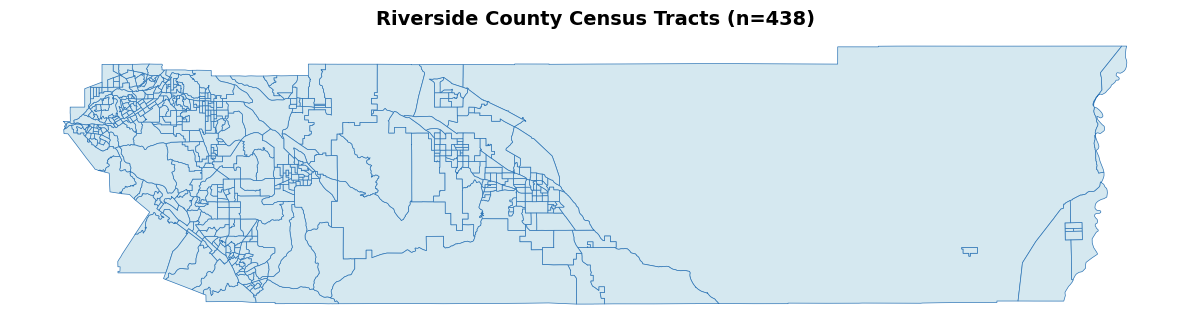

In [7]:
# Standardize GEOID

# Ensure GEOID is a string (critical for merging with Census ACS data)
tracts['GEOID'] = tracts['GEOID'].astype(str).str.zfill(11)

# Verify the format — should be 11 characters like '06065010101'
print('GEOID format check:')
print(tracts['GEOID'].head(3).tolist())
print(f'GEOID length: {tracts["GEOID"].str.len().unique()} (should be [11])')

# Quick map to confirm the county boundary looks right
fig, ax = plt.subplots(figsize=(12, 8))
tracts.plot(ax=ax, facecolor='#D5E8F0', edgecolor='#2E75B6', linewidth=0.5)
ax.set_title('Riverside County Census Tracts (n=438)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_tract_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Download Census API Demographic Data

> **Concept - American Community Survey (ACS):** The ACS is a rolling survey conducted by the U.S. Census Bureau that publishes annual estimates for small geographies like census tracts. We use the 5-year estimates (more stable than 1-year) to get population, income, educational attainment, and employment data for every Riverside County tract. The Census Bureau provides a free REST API to query this data without downloading large files.

### 3.1 Understand the Census API Format
The Census API uses URL-based queries with this pattern:
```
https://api.census.gov/data/{year}/acs/acs5
  ?get={variable_codes}
  &for=tract:*
  &in=state:{state_fips}%20county:{county_fips}
  &key={your_api_key}
```
Variable codes we use:
- `B01003_001E` — Total population
- `B19013_001E` — Median household income  
- `B23025_005E` — Unemployed (civilian labor force)
- `B23025_003E` — Civilian labor force total
- `B15003_022E` — Bachelor's degree holders
- `B15003_001E` — Total population 25+ years

### 3.2 Write the API Query Function

In [8]:
# Census API query function

def query_census_acs(variables, year=2022):
    """
    Pull ACS 5-year estimates for all Riverside County tracts.

    Parameters:
        variables : list of str  — Census variable codes (e.g. ['B01003_001E'])
        year      : int          — ACS data year (default 2022)

    Returns:
        pd.DataFrame with a column for each variable plus a GEOID column
    """
    base_url = f'https://api.census.gov/data/{year}/acs/acs5'
    params = {
        'get'   : 'NAME,' + ','.join(variables),
        'for'   : 'tract:*',
        'in'    : f'state:{STATE_FIPS} county:{COUNTY_FIPS}',
        'key'   : CENSUS_API_KEY
    }
    response = requests.get(base_url, params=params)
    response.raise_for_status()  # raise an error if request failed

    data = response.json()
    df = pd.DataFrame(data[1:], columns=data[0])   # row 0 = headers

    # Build 11-digit GEOID from the component parts
    df['GEOID'] = df['state'] + df['county'] + df['tract']
    df['GEOID'] = df['GEOID'].str.zfill(11)

    # Drop the component columns, keep only GEOID + variables
    df = df.drop(columns=['NAME', 'state', 'county', 'tract'])

    # Convert variable columns from string to numeric
    for col in variables:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

print('Census API function defined.')

Census API function defined.


### 3.3 Pull the Demographic Variables

In [9]:
# Pull all demographic variables

print('Pulling Census ACS data for Riverside County tracts...')

# Population
df_pop = query_census_acs(['B01003_001E'])
df_pop = df_pop.rename(columns={'B01003_001E': 'total_pop'})
print(f'  Population data: {len(df_pop)} tracts')

# Income
df_inc = query_census_acs(['B19013_001E'])
df_inc = df_inc.rename(columns={'B19013_001E': 'median_income'})
print(f'  Income data:     {len(df_inc)} tracts')

# Employment (unemployment rate = unemployed / labor force)
df_emp = query_census_acs(['B23025_003E', 'B23025_005E'])
df_emp = df_emp.rename(columns={'B23025_003E': 'labor_force', 'B23025_005E': 'unemployed'})
df_emp['unemp_rate'] = df_emp['unemployed'] / df_emp['labor_force'] * 100
print(f'  Employment data: {len(df_emp)} tracts')

# Education (% with bachelor's degree or higher)
df_edu = query_census_acs(['B15003_001E', 'B15003_022E'])
df_edu = df_edu.rename(columns={'B15003_001E': 'pop_25plus', 'B15003_022E': 'bachelors'})
df_edu['pct_bachelors'] = df_edu['bachelors'] / df_edu['pop_25plus'] * 100
print(f'  Education data:  {len(df_edu)} tracts')


Pulling Census ACS data for Riverside County tracts...
  Population data: 518 tracts
  Income data:     518 tracts
  Employment data: 518 tracts
  Education data:  518 tracts


### 3.4 Merge all Demographic Data

In [10]:
# Merge all demographic DataFrames into one

# Start with population and merge others in sequence
demo = df_pop.merge(df_inc, on='GEOID', how='left')
demo = demo.merge(df_emp[['GEOID', 'unemp_rate']], on='GEOID', how='left')
demo = demo.merge(df_edu[['GEOID', 'pct_bachelors']], on='GEOID', how='left')

# Replace invalid values (-666666666 = Census code for 'data not available')
demo = demo.replace(-666666666, np.nan)
demo = demo.replace(-666666666.0, np.nan)

print(f'Merged demographic table: {demo.shape}')
print(f'Missing values per column:')
print(demo.isnull().sum())
print('\nSample rows:')
print(demo.head(3).to_string())

Merged demographic table: (518, 5)
Missing values per column:
total_pop        0
GEOID            0
median_income    3
unemp_rate       2
pct_bachelors    1
dtype: int64

Sample rows:
   total_pop        GEOID  median_income  unemp_rate  pct_bachelors
0       1187  06065030101        65250.0    3.092784      19.111111
1       2155  06065030103       100074.0   10.628019      11.015119
2       7161  06065030104        82177.0    8.938547       7.969593


## 4. Merge Demographics with Tract Geometries

### 4.1 Verify GEOID Alignment Before Merging

Always check that both sides of your join use the same GEOID format before merging.

In [11]:
# GEOID format diagnostic

print('=== GEOID FORMAT CHECK ===')
print(f'Shapefile GEOIDs (tracts):')
print(f'  Type:   {tracts["GEOID"].dtype}')
print(f'  Length: {tracts["GEOID"].str.len().unique()}')
print(f'  Sample: {tracts["GEOID"].head(3).tolist()}')

print(f'\nCensus API GEOIDs (demo):')
print(f'  Type:   {demo["GEOID"].dtype}')
print(f'  Length: {demo["GEOID"].str.len().unique()}')
print(f'  Sample: {demo["GEOID"].head(3).tolist()}')

# Check overlap
overlap = set(tracts['GEOID']) & set(demo['GEOID'])
print(f'\nMatching GEOIDs: {len(overlap)} out of {len(tracts)} tracts')
print('GOOD: All tracts match!' if len(overlap) == len(tracts) else 'WARNING: Some tracts do not match!')

=== GEOID FORMAT CHECK ===
Shapefile GEOIDs (tracts):
  Type:   str
  Length: [11]
  Sample: ['06065046103', '06065031001', '06065043211']

Census API GEOIDs (demo):
  Type:   str
  Length: [11]
  Sample: ['06065030101', '06065030103', '06065030104']

Matching GEOIDs: 518 out of 518 tracts
GOOD: All tracts match!


### 4.2 - Spatial Join: Merge Demographics into the GeoDataFrame

In [12]:
# Merge demographics into the tract GeoDataFrame

# Left merge: keeps all 438 tracts even if some have missing demographic data
gdf = tracts.merge(demo, on='GEOID', how='left')

print(f'GeoDataFrame shape: {gdf.shape}')
print(f'Columns: {list(gdf.columns)}')
print(f'CRS: {gdf.crs}')
print(f'\nFirst 3 rows:')
print(gdf[['GEOID', 'total_pop', 'median_income', 'unemp_rate']].head(3))

GeoDataFrame shape: (518, 18)
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry', 'total_pop', 'median_income', 'unemp_rate', 'pct_bachelors']
CRS: EPSG:4269

First 3 rows:
         GEOID  total_pop  median_income  unemp_rate
0  06065046103       3109        73977.0    4.541955
1  06065031001       4944        92765.0    4.747884
2  06065043211       7289       117037.0    8.056042


### 4.3 Reproject to a Metric CRS

EPSG:3857 (Web Mercator) uses meters, which is required for calculating areas and densities

In [13]:
# Reproject to Web Mercator for distance-based calculations

gdf = gdf.to_crs(epsg=3857)

# Calculate area in square kilometers
gdf['area_km2'] = gdf.geometry.area / 1_000_000  # convert m² to km²

print(f'CRS after reprojection: {gdf.crs}')
print(f'\nArea statistics (km²):')
print(gdf['area_km2'].describe().round(2))

CRS after reprojection: EPSG:3857

Area statistics (km²):
count      518.00
mean        52.94
std        634.36
min          0.70
25%          2.69
50%          4.64
75%         12.34
max      14313.07
Name: area_km2, dtype: float64


## 5. Extract Commercial POIs from OpenStreetMap

### 5.1 Define the OSM Tags to Extract

OSM uses a key-value tagging system. We pull multiple tag types to capture all commercial activity.

In [15]:
# Define commercial POI tags

# These tags capture different types of commercial activity in OSM
COMMERCIAL_TAGS = {
    'amenity': [
        'restaurant', 'fast_food', 'cafe', 'bar', 'pub',
        'bank', 'pharmacy', 'fuel', 'car_wash', 'car_rental',
        'hospital', 'clinic', 'doctors', 'dentist',
        'marketplace', 'food_court'
    ],
    'shop'   : True,   # All shop types (grocery, clothing, hardware, etc.)
    'office' : True,   # All office types (legal, insurance, estate agent, etc.)
    'leisure': ['fitness_centre', 'sports_centre', 'stadium'],
    'landuse': ['retail', 'commercial', 'industrial'],
}

print('Commercial tags defined.')
print(f'Will extract POIs for {len(CITIES)} cities.')

Commercial tags defined.
Will extract POIs for 9 cities.


### 5.2 Extract POIs for All Riverside County Cities

In [16]:
# Extract POIs (takes 5–10 minutes)

all_pois = []

for city in CITIES:
    try:
        print(f'Extracting POIs: {city}...')
        gdf_city = ox.features_from_place(city, tags=COMMERCIAL_TAGS)

        # Keep only point geometries (some OSM features are polygons)
        gdf_city = gdf_city[gdf_city.geometry.geom_type == 'Point'].copy()

        # Add city name for reference
        gdf_city['source_city'] = city.split(',')[0]

        # Keep only the columns we need
        keep_cols = ['geometry', 'source_city', 'name']
        available = [c for c in keep_cols if c in gdf_city.columns]
        gdf_city = gdf_city[available]

        all_pois.append(gdf_city)
        print(f'  -> {len(gdf_city)} POIs found')

    except Exception as e:
        print(f'  * Skipping {city}: {e}')

# Combine all cities into one GeoDataFrame
pois = pd.concat(all_pois, ignore_index=True)
pois = pois.to_crs(epsg=3857)  # match our tract CRS

print(f'\nTotal commercial POIs extracted: {len(pois)}')
print(f'POIs by city:')
print(pois['source_city'].value_counts().to_string())

Extracting POIs: Riverside, California, USA...
  -> 856 POIs found
Extracting POIs: Corona, California, USA...
  -> 283 POIs found
Extracting POIs: Moreno Valley, California, USA...
  -> 145 POIs found
Extracting POIs: Temecula, California, USA...
  -> 581 POIs found
Extracting POIs: Murrieta, California, USA...
  -> 353 POIs found
Extracting POIs: Palm Springs, California, USA...
  -> 280 POIs found
Extracting POIs: Indio, California, USA...
  -> 66 POIs found
Extracting POIs: Hemet, California, USA...
  -> 37 POIs found
Extracting POIs: Perris, California, USA...
  -> 56 POIs found

Total commercial POIs extracted: 2657
POIs by city:
source_city
Riverside        856
Temecula         581
Murrieta         353
Corona           283
Palm Springs     280
Moreno Valley    145
Indio             66
Perris            56
Hemet             37


## 6. Spatial Join & Business Density

### 6.1 Run the Spatial Join

Point-in-polygon: Assign each POI to the census tract that contains it.

In [17]:
# Spatial join: assign each POI to its census tract

# Ensure both layers are in the same CRS
print(f'Tract CRS:  {gdf.crs}')
print(f'POI CRS:    {pois.crs}')

# Spatial join: point-in-polygon
pois_joined = gpd.sjoin(
    pois,                          # left: points we want to assign
    gdf[['GEOID', 'geometry']],    # right: polygons to assign to
    how='inner',                   # only keep POIs that fall within a tract
    predicate='within'
)

print(f'\nPOIs successfully joined to tracts: {len(pois_joined)}')
print(f'POIs outside any tract (dropped): {len(pois) - len(pois_joined)}')

Tract CRS:  EPSG:3857
POI CRS:    EPSG:3857

POIs successfully joined to tracts: 2657
POIs outside any tract (dropped): 0


### 6.2 Count POIs per Tract

In [18]:
# Count POIs per tract and calculate density

# Count how many POIs fall in each tract
poi_counts = pois_joined.groupby('GEOID').size().reset_index(name='poi_count')

# Merge counts back into the main GeoDataFrame
gdf = gdf.merge(poi_counts, on='GEOID', how='left')

# Tracts with no POIs should have 0 (not NaN)
gdf['poi_count'] = gdf['poi_count'].fillna(0).astype(int)

# Calculate business density: POIs per square kilometer
gdf['biz_density'] = gdf['poi_count'] / gdf['area_km2']

# Replace infinite values (area = 0 edge case)
gdf['biz_density'] = gdf['biz_density'].replace([np.inf, -np.inf], 0)

print('Business density calculated!')
print(gdf[['GEOID', 'poi_count', 'area_km2', 'biz_density']].describe().round(2))

Business density calculated!
       poi_count  area_km2  biz_density
count     518.00    518.00       518.00
mean        5.13     52.94         1.21
std        18.03    634.36         3.64
min         0.00      0.70         0.00
25%         0.00      2.69         0.00
50%         0.00      4.64         0.00
75%         3.00     12.34         0.64
max       300.00  14313.07        40.65


### 6.3 Map the Business Density

A choropleth fills each tract with a color based on its business density value.

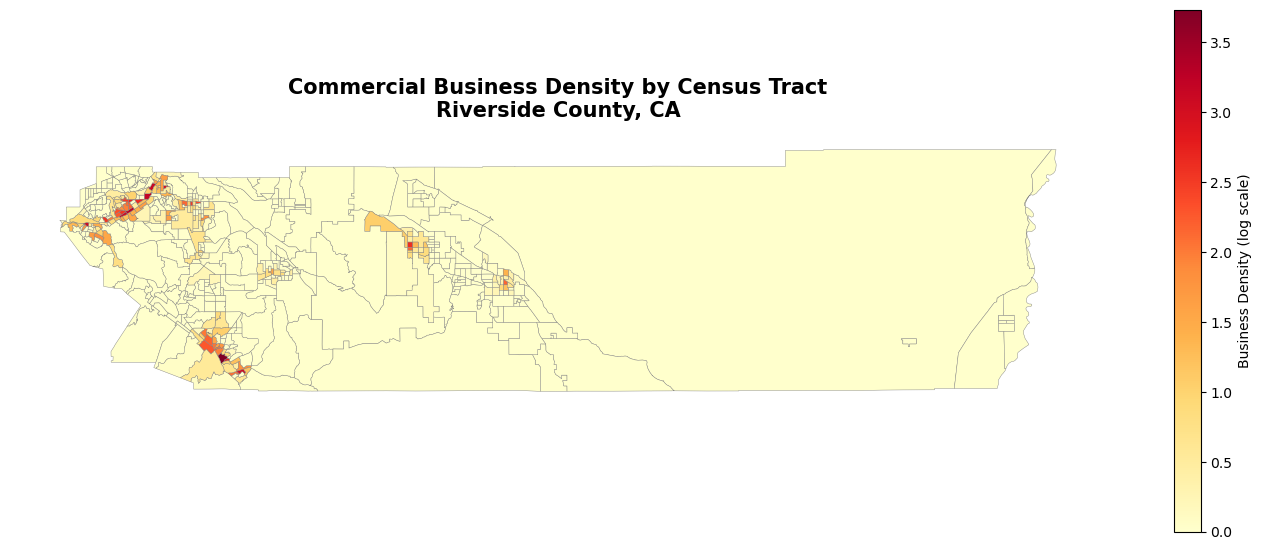

In [19]:
# Choropleth map of business density

fig, ax = plt.subplots(figsize=(14, 9))

# Log scale handles the wide range of values
gdf['biz_density_log'] = np.log1p(gdf['biz_density'])  # log1p = log(1 + x)
gdf.plot(
    column='biz_density_log',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Business Density (log scale)', 'shrink': 0.6},
    linewidth=0.3,
    edgecolor='grey',
    ax=ax
)

ax.set_title('Commercial Business Density by Census Tract\nRiverside County, CA',
             fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_biz_density_choropleth.png', dpi=150, bbox_inches='tight')

plt.show()

## 7. Spatial Autocorrelation Analysis (Moran's I)

### 7.1 Build the Spatial Weights Matrix

Queen contiguity considers tracts that share a border or corner as neighbors.

In [20]:
# Build Queen contiguity spatial weights matrix

# Drop tracts with missing geometry
gdf_valid = gdf[gdf.geometry.is_valid & ~gdf.geometry.is_empty].copy()
gdf_valid = gdf_valid.reset_index(drop=True)

# Build Queen weights (neighbors share an edge or corner)
w = Queen.from_dataframe(gdf_valid, silence_warnings=True)

# Row-standardize: each row sums to 1 (standard practice)
w.transform = 'r'

print(f'Tracts used for analysis: {len(gdf_valid)}')
print(f'Average number of neighbors per tract: {w.mean_neighbors:.1f}')
print(f'Islands (tracts with 0 neighbors): {w.islands}')

Tracts used for analysis: 518
Average number of neighbors per tract: 6.2
Islands (tracts with 0 neighbors): []


### 7.2 Compute Global Moran's I

Moran;s I ranges from -1 (dispersed) to +1 (clustered). A value near 0 indicateds random distribution.

In [21]:
# Global Moran's I for business density

# Extract business density as a numpy array
y = gdf_valid['biz_density'].values

# Run Moran's I
moran = Moran(y, w)

print(f"=== Global Moran's I ===")
print(f"I statistic:  {moran.I:.4f}")
print(f"p-value:      {moran.p_sim:.4f}")
print()
if moran.p_sim < 0.05:
    if moran.I > 0:
        print('Result: Statistically significant POSITIVE spatial autocorrelation.')
        print('Interpretation: High-density tracts cluster near other high-density tracts.')
    else:
        print('Result: Statistically significant NEGATIVE spatial autocorrelation.')
else:
    print('Result: No significant spatial clustering detected.')

=== Global Moran's I ===
I statistic:  0.2361
p-value:      0.0010

Result: Statistically significant POSITIVE spatial autocorrelation.
Interpretation: High-density tracts cluster near other high-density tracts.


### 7.3 Generate LISA Local Cluster Map
LISA identifies individual tracts as:
- **High-High** — commercial hotspot (high in a high area)
- **Low-Low** — commercial cold spot (low in a low area)
- **High-Low** — outlier: high in a low-density area
- **Low-High** — outlier: low in a high-density area

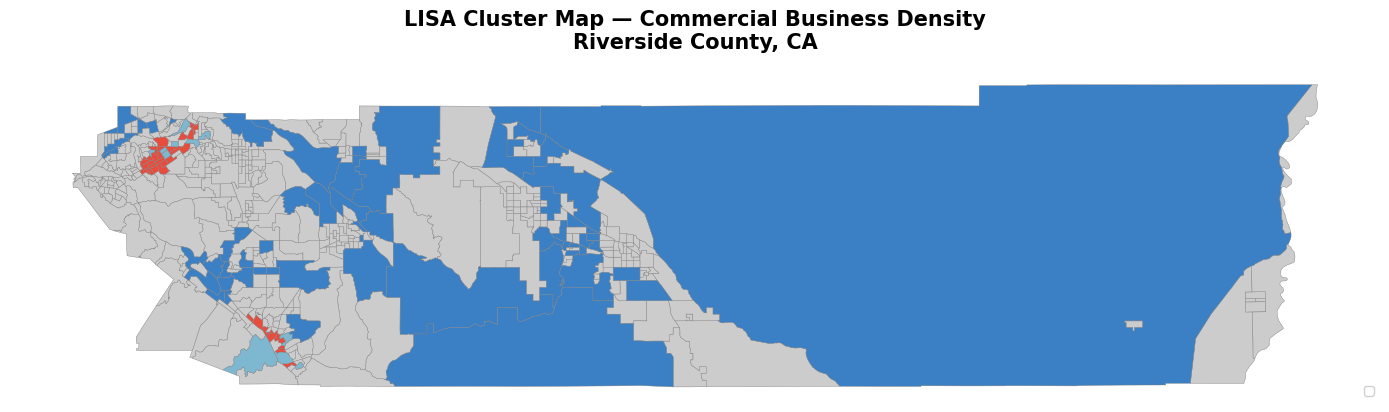

In [22]:
# LISA local cluster map

# Compute Local Moran's I
lisa = Moran_Local(y, w)

# Add LISA cluster labels to GeoDataFrame
# Significance threshold: p < 0.05
gdf_valid['lisa_cluster'] = 0   # 0 = Not significant
sig = lisa.p_sim < 0.05
gdf_valid.loc[sig, 'lisa_cluster'] = lisa.q[sig]

# Map cluster codes to labels
cluster_labels = {0: 'Not Significant', 1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
cluster_colors = {0: '#CCCCCC', 1: '#E84C3D', 2: '#7DB7D0', 3: '#3B7FC4', 4: '#F07F00'}
gdf_valid['lisa_label'] = gdf_valid['lisa_cluster'].map(cluster_labels)

# Plot
fig, ax = plt.subplots(figsize=(14, 9))
for cluster_id, label in cluster_labels.items():
    subset = gdf_valid[gdf_valid['lisa_cluster'] == cluster_id]
    subset.plot(ax=ax, color=cluster_colors[cluster_id], edgecolor='grey',
                linewidth=0.3, label=f'{label} (n={len(subset)})')

ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title('LISA Cluster Map — Commercial Business Density\nRiverside County, CA',
             fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_lisa_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Machine Learning Clustering
### 8.1 DBSCAN — Find Geographic Commercial Hotspots
DBSCAN finds dense clusters of POIs without requiring you to specify the number of clusters in advance.

In [23]:
# DBSCAN on POI coordinates

# Extract coordinates of all commercial POIs
# Note: pois is still in EPSG:3857 — reproject to lat/lon for haversine metric
pois_ll = pois.to_crs(epsg=4326)
coords = np.array([[geom.y, geom.x] for geom in pois_ll.geometry])

# DBSCAN parameters:
#   eps: neighborhood radius in degrees (~0.008 degrees ≈ ~900m)
#   min_samples: minimum POIs to form a cluster core
db = DBSCAN(eps=0.008, min_samples=15, algorithm='ball_tree', metric='haversine')
pois['dbscan_cluster'] = db.fit_predict(np.radians(coords))

n_clusters = len(set(pois['dbscan_cluster'])) - (1 if -1 in pois['dbscan_cluster'] else 0)
n_noise    = list(pois['dbscan_cluster']).count(-1)

print(f'DBSCAN results:')
print(f'  Clusters found:      {n_clusters}')
print(f'  Noise points:        {n_noise} ({n_noise/len(pois)*100:.1f}%)')
print(f'  Clustered points:    {len(pois) - n_noise}')

DBSCAN results:
  Clusters found:      1
  Noise points:        0 (0.0%)
  Clustered points:    2657


### 8.2 K-Means — Segment Tracts by Economic Profile
Use the elbow method to choose the right number of clusters. Look for the point where the inertia curve bends most sharply.

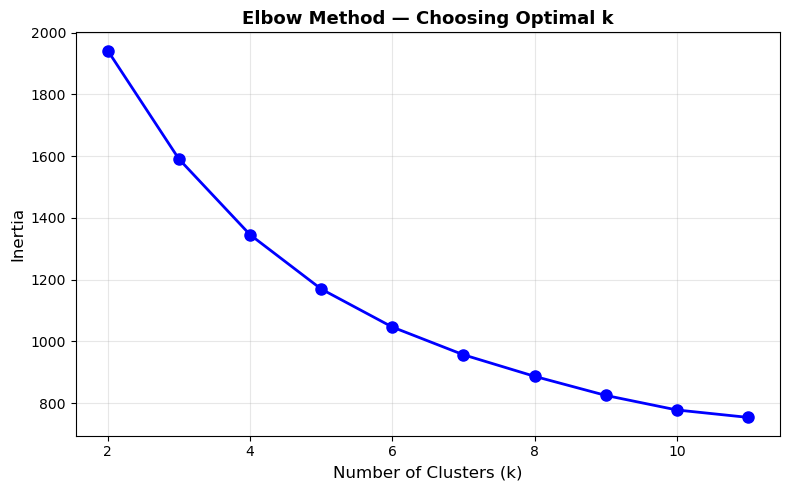

Look for the "elbow" — where the curve bends most sharply.


In [24]:
# K-Means tract segmentation (elbow method)

# Select features for clustering
features = ['biz_density', 'median_income', 'unemp_rate', 'pct_bachelors', 'total_pop']

# Prepare the feature matrix — drop rows with missing values
km_data   = gdf_valid[features].dropna().copy()
valid_idx = km_data.index   # track which tracts we're using

# Standardize: K-Means is sensitive to scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(km_data)

# Elbow method: find the optimal number of clusters
inertias = []
k_range  = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Choosing Optimal k', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Look for the "elbow" — where the curve bends most sharply.')

### 8.3 Apply K-Means with Chosen k
> **Adjust `CHOSEN_K`** based on what you see in your elbow curve above. `k=6` is typical for this dataset.

In [25]:
# Apply K-Means with k=6

CHOSEN_K = 6   # Adjust based on your elbow curve

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
cluster_labels_arr = km_final.fit_predict(X_scaled)

# Add cluster assignments back to GeoDataFrame
gdf_valid.loc[valid_idx, 'km_cluster'] = cluster_labels_arr
gdf_valid['km_cluster'] = gdf_valid['km_cluster'].fillna(-1).astype(int)

# Print cluster profiles to help with labeling
print('=== Cluster Profiles ===')
cluster_profile = gdf_valid[gdf_valid['km_cluster'] >= 0].groupby('km_cluster')[features].mean().round(1)
print(cluster_profile.to_string())

=== Cluster Profiles ===
            biz_density  median_income  unemp_rate  pct_bachelors  total_pop
km_cluster                                                                  
0                   0.8        76961.2         5.4           10.2     4861.6
1                   0.5        78045.4         8.4           21.3     2941.1
2                   1.0       113589.3         6.6           19.2     8634.0
3                  18.0        67377.7         5.9           13.7     5022.9
4                   0.6       135364.5         4.5           23.9     4441.1
5                   0.5        52354.1        12.6            6.4     3815.0


### 8.4 Label the Clusters
> **Adjust the `CLUSTER_NAMES` dictionary** based on the profiles printed in Cell 23. The labels below are typical — update them to match your output.

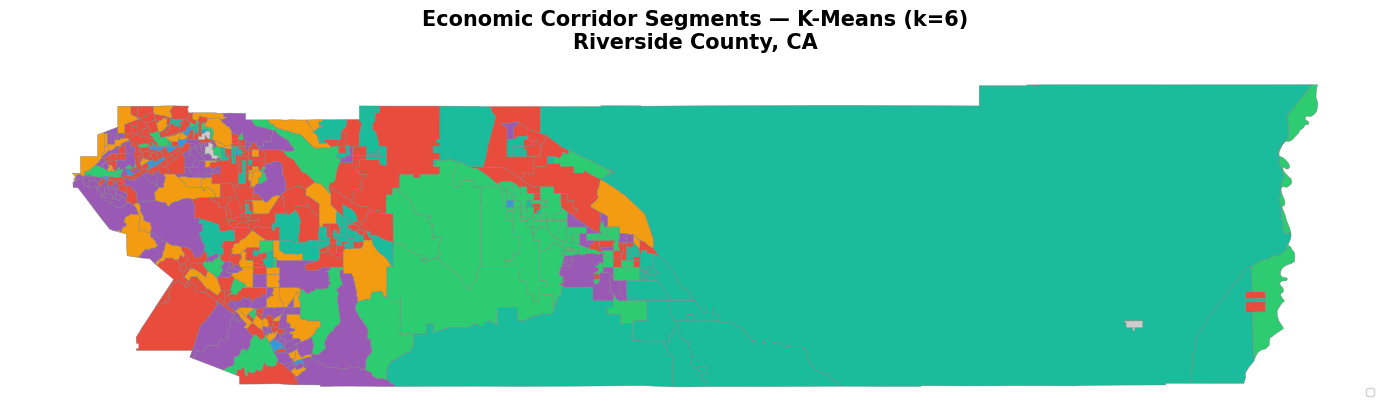

In [26]:
# Label clusters based on their profiles

# Adjust these labels based on YOUR cluster profiles
# Key signals: biz_density (high=commercial), median_income, unemp_rate
CLUSTER_NAMES = {
    0: 'Logistics & Industrial Hub',
    1: 'Affluent Retail Corridor',
    2: 'Tourist & Hospitality Zone',
    3: 'Low-Density Opportunity Zone',
    4: 'Mixed Urban Core',
    5: 'Agricultural Service Area',
   -1: 'Insufficient Data',
}

CLUSTER_COLORS = {
    0: '#E84C3D',   # Red     — logistics
    1: '#2ECC71',   # Green   — affluent retail
    2: '#F39C12',   # Orange  — tourism
    3: '#3498DB',   # Blue    — opportunity
    4: '#9B59B6',   # Purple  — mixed urban
    5: '#1ABC9C',   # Teal    — agricultural
   -1: '#CCCCCC',   # Gray    — no data
}

gdf_valid['cluster_name'] = gdf_valid['km_cluster'].map(CLUSTER_NAMES)

# Map of cluster segments
fig, ax = plt.subplots(figsize=(14, 9))
for cluster_id, name in CLUSTER_NAMES.items():
    subset = gdf_valid[gdf_valid['km_cluster'] == cluster_id]
    if len(subset) > 0:
        subset.plot(ax=ax, color=CLUSTER_COLORS[cluster_id],
                    edgecolor='grey', linewidth=0.3, label=f'{name} (n={len(subset)})')

ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.set_title('Economic Corridor Segments — K-Means (k=6)\nRiverside County, CA',
             fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_kmeans_corridors.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Multi-Criteria Opportunity Score
### 9.1 Define the Scoring Variables & Weights

| Variable | Weight | Direction | Rationale |
|---|---|---|---|
| Population | 20% | Higher = better | More potential customers |
| Median Income | 20% | Higher = better | Purchasing power |
| Unemployment Rate | 20% | Lower = better (inverted) | Stable workforce |
| Business Density | 25% | Lower = better (inverted) | Opportunity gap |
| HUD Opportunity Zone | 15% | Yes = better | Federal incentives |

In [27]:
# Define scoring variables

WEIGHTS = {
    'score_pop':   0.20,   # higher population = more customers
    'score_inc':   0.20,   # higher income = more purchasing power
    'score_unemp': 0.20,   # lower unemployment = more stable workforce (inverted)
    'score_gap':   0.25,   # lower business density = bigger opportunity gap (inverted)
    'score_oz':    0.15,   # HUD Opportunity Zone designation
}

print('Weights defined. Total weight:', sum(WEIGHTS.values()))

Weights defined. Total weight: 1.0


### 9.2 Load HUD Opportunity Zones

In [28]:
# Load HUD Opportunity Zone designations

oz_url = 'https://hudgis-hud.opendata.arcgis.com/datasets/HUD::opportunity-zones.csv'

try:
    oz_df = pd.read_csv(oz_url)
    oz_df['GEOID'] = oz_df['GEOID'].astype(str).str.zfill(11)
    oz_riverside   = oz_df[oz_df['GEOID'].str.startswith('06065')]
    oz_geoids      = set(oz_riverside['GEOID'].tolist())
    print(f'HUD Opportunity Zones in Riverside County: {len(oz_geoids)}')
except Exception as e:
    print(f'HUD URL unavailable ({e}) — using empty OZ list.')
    oz_geoids = set()   # results in oz_score = 0 for all tracts (still valid)

gdf_valid['is_oz'] = gdf_valid['GEOID'].isin(oz_geoids).astype(int)
print(f'OZ tracts flagged: {gdf_valid["is_oz"].sum()}')

HUD URL unavailable ('GEOID') — using empty OZ list.
OZ tracts flagged: 0


### 9.3 Normalize Variables to 0-100 Percentile Scale

In [29]:
# Normalize each variable to percentile rank

def percentile_score(series, invert=False):
    """
    Convert a series to a 0–100 percentile rank score.
    invert=True for variables where lower = more opportunity
    (e.g. business density, unemployment rate).
    """
    ranked = series.rank(pct=True, na_option='keep') * 100
    ranked = ranked.fillna(50)   # missing data gets median score
    if invert:
        ranked = 100 - ranked    # flip so lower original = higher score
    return ranked

# Apply normalization
gdf_valid['score_pop']   = percentile_score(gdf_valid['total_pop'])
gdf_valid['score_inc']   = percentile_score(gdf_valid['median_income'])
gdf_valid['score_unemp'] = percentile_score(gdf_valid['unemp_rate'], invert=True)
gdf_valid['score_gap']   = percentile_score(gdf_valid['biz_density'], invert=True)
gdf_valid['score_oz']    = gdf_valid['is_oz'] * 100   # binary: 0 or 100

print('Normalized scores:')
score_cols = list(WEIGHTS.keys())
print(gdf_valid[score_cols].describe().round(1).to_string())

Normalized scores:
       score_pop  score_inc  score_unemp  score_gap  score_oz
count      518.0      518.0        518.0      518.0     518.0
mean        50.1       50.1         49.9       49.9       0.0
std         28.9       28.8         28.8       24.9       0.0
min          0.2        0.2          0.0        0.0       0.0
25%         25.2       25.3         25.0       25.0       0.0
50%         50.1       50.0         50.0       68.1       0.0
75%         75.0       74.9         74.8       68.1       0.0
max        100.0      100.0         99.4       68.1       0.0


### 9.4 Calculate the Composite Opportuntiy Score

In [30]:
# Compute weighted composite score

gdf_valid['opportunity_score'] = sum(
    gdf_valid[col] * weight for col, weight in WEIGHTS.items()
)

print('Opportunity Score distribution:')
print(gdf_valid['opportunity_score'].describe().round(2))

# Get the top 20 tracts
top20 = (
    gdf_valid[['GEOID', 'opportunity_score', 'cluster_name',
               'total_pop', 'median_income', 'unemp_rate', 'biz_density', 'is_oz']]
    .sort_values('opportunity_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Rename columns for readability
top20 = top20.rename(columns={
    'opportunity_score': 'Score',
    'cluster_name':      'Corridor Type',
    'total_pop':         'Population',
    'median_income':     'Med. Income ($)',
    'unemp_rate':        'Unemp. Rate (%)',
    'biz_density':       'Biz Density (POI/km²)',
    'is_oz':             'HUD OZ?',
})
top20['Rank'] = range(1, 21)
top20 = top20.set_index('Rank')

print('\n=== TOP 20 OPPORTUNITY TRACTS ===')
print(top20[['Score', 'Corridor Type', 'Population', 'Med. Income ($)']].to_string())

# Save to CSV
top20.to_csv(f'{OUTPUT_DIR}/top20_opportunity_tracts.csv')


Opportunity Score distribution:
count    518.00
mean      42.50
std       13.70
min        6.56
25%       32.80
50%       42.90
75%       52.60
max       74.10
Name: opportunity_score, dtype: float64

=== TOP 20 OPPORTUNITY TRACTS ===
          Score               Corridor Type  Population  Med. Income ($)
Rank                                                                    
1     74.099546            Mixed Urban Core        7069         178026.0
2     72.539126  Tourist & Hospitality Zone       17697         152684.0
3     72.421716  Tourist & Hospitality Zone       12388         142500.0
4     71.492440  Tourist & Hospitality Zone        8221         126250.0
5     70.845978            Mixed Urban Core        6746         201184.0
6     69.797366            Mixed Urban Core        6962         161583.0
7     69.477016  Tourist & Hospitality Zone        8481         130335.0
8     69.305763            Mixed Urban Core        5648         162407.0
9     69.008753  Tourist & Hospital

## 10. Geographically Weighted Regression (GWR)
GWR fits a separate regression model for every tract, weighted by geographic proximity. This reveals where relationships between variables are strong vs. weak — what GIS analysts call **spatial non-stationarity**.

### 10.1 Prepare the GWR Input Data

In [31]:
# Prepare GWR data

# GWR requires no missing values in the feature or target columns
gwr_features = ['median_income', 'unemp_rate', 'total_pop']
gwr_target   = 'biz_density'

gwr_data = gdf_valid[[gwr_target] + gwr_features + ['geometry']].dropna()
gwr_data = gwr_data.reset_index(drop=True)

print(f'GWR dataset: {len(gwr_data)} tracts (after dropping {len(gdf_valid) - len(gwr_data)} with missing data)')

# Extract coordinates (centroid of each tract)
coords_gwr = np.column_stack([
    gwr_data.geometry.centroid.x,
    gwr_data.geometry.centroid.y
])

# Target variable (business density)
y_gwr = gwr_data[gwr_target].values.reshape(-1, 1)

# Predictor variables
X_gwr = gwr_data[gwr_features].values

print(f'Coordinates shape: {coords_gwr.shape}')
print(f'y shape: {y_gwr.shape}')
print(f'X shape: {X_gwr.shape}')

GWR dataset: 515 tracts (after dropping 3 with missing data)
Coordinates shape: (515, 2)
y shape: (515, 1)
X shape: (515, 3)


### 10.2 Select Bandwidth
**This cell takes 5–10 minutes.** The `Sel_BW` function searches for the optimal bandwidth using the AICc criterion.

In [32]:
# Find optimal GWR bandwidth (takes 5–10 minutes)

print('Searching for optimal bandwidth (this takes a few minutes)...')

bw_selector = Sel_BW(coords_gwr, y_gwr, X_gwr)
optimal_bw  = bw_selector.search(criterion='AICc')

print(f'Optimal bandwidth: {optimal_bw:.0f} neighbors')

Searching for optimal bandwidth (this takes a few minutes)...
Optimal bandwidth: 132 neighbors


### 10.3 Fit the GWR Model

In [33]:
# Fit the GWR model

gwr_model   = GWR(coords_gwr, y_gwr, X_gwr, bw=optimal_bw)
gwr_results = gwr_model.fit()

print(f'GWR model fit summary:')
print(f'  Observations: {gwr_results.n}')
print(f'  AICc:         {gwr_results.aicc:.2f}')
print(f'  R-squared:    {gwr_results.R2:.4f}')

# Extract local coefficients
# Columns: intercept, median_income, unemp_rate, total_pop
coeff_cols   = ['intercept', 'coeff_income', 'coeff_unemp', 'coeff_pop']
gwr_coeff_df = pd.DataFrame(
    gwr_results.params,
    columns=coeff_cols,
    index=gwr_data.index
)

# Add local R² and combine with geometry
gwr_coeff_df['local_r2'] = gwr_results.localR2
gwr_geo = gwr_data[['geometry']].join(gwr_coeff_df)

print(f'\nLocal R² statistics:')
print(gwr_geo['local_r2'].describe().round(3))

GWR model fit summary:
  Observations: 515
  AICc:         2738.61
  R-squared:    0.2250

Local R² statistics:
count    515.000
mean       0.118
std        0.134
min       -1.000
25%        0.056
50%        0.128
75%        0.204
max        0.321
Name: local_r2, dtype: float64


### 10.4 Map the Local R² and Income Coefficient

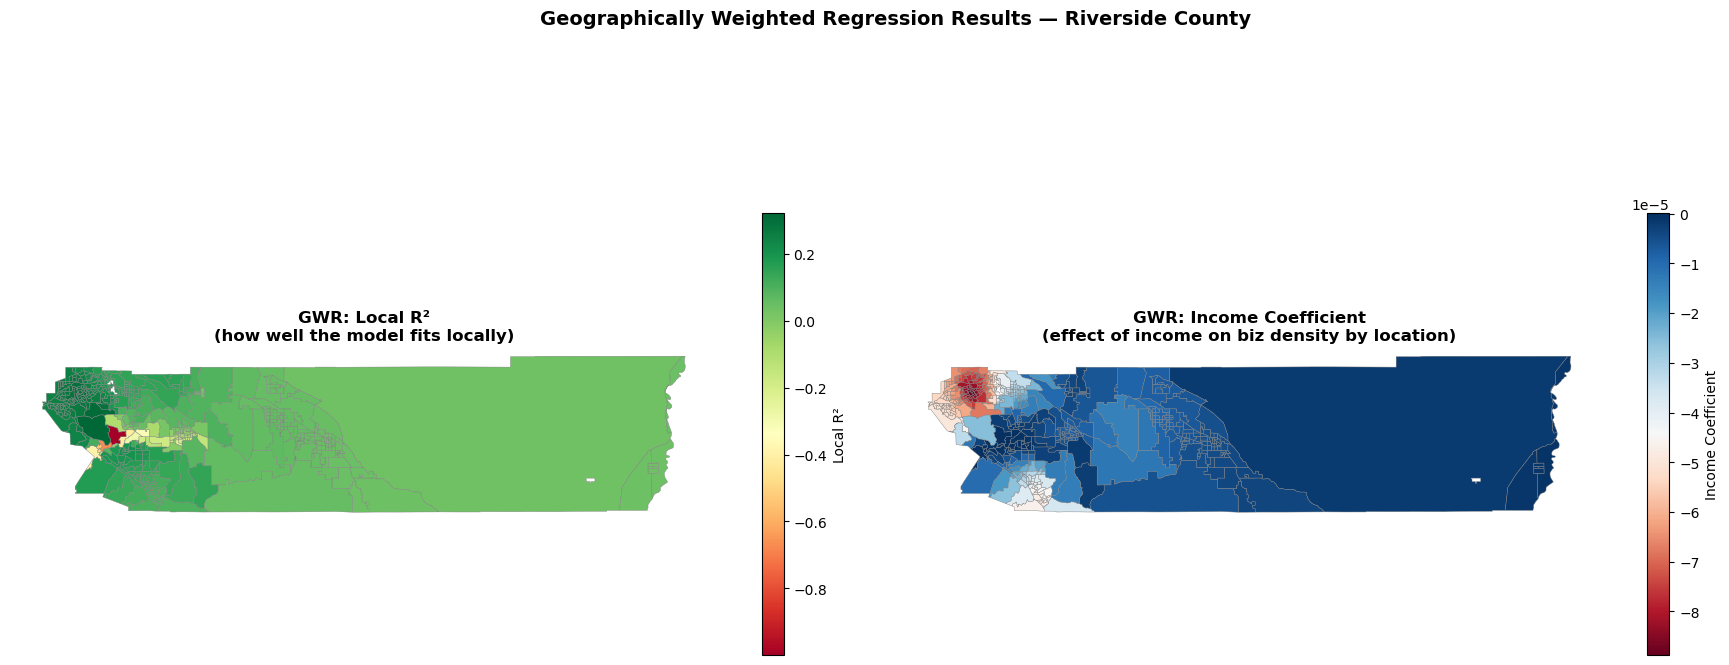

In [34]:
# Map GWR local R² and income coefficient

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Local R²
gwr_geo.plot(column='local_r2', cmap='RdYlGn', legend=True,
             legend_kwds={'label': 'Local R²', 'shrink': 0.6},
             linewidth=0.3, edgecolor='grey', ax=axes[0])
axes[0].set_title('GWR: Local R²\n(how well the model fits locally)', fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# Right: Income coefficient
gwr_geo.plot(column='coeff_income', cmap='RdBu', legend=True,
             legend_kwds={'label': 'Income Coefficient', 'shrink': 0.6},
             linewidth=0.3, edgecolor='grey', ax=axes[1])
axes[1].set_title('GWR: Income Coefficient\n(effect of income on biz density by location)', fontsize=12, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('Geographically Weighted Regression Results — Riverside County',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_gwr_maps.png', dpi=150, bbox_inches='tight')

plt.show()


## 11. Build the Interactive 

### 11.1 Intialize the Base Map

In [35]:
# Initialize the Folium map

# Reproject back to EPSG:4326 for Folium (Folium uses lat/lon)
gdf_map  = gdf_valid.to_crs(epsg=4326)
pois_map = pois.to_crs(epsg=4326)

# Center the map on Riverside County centroid
center_lat = gdf_map.geometry.centroid.y.mean()
center_lon = gdf_map.geometry.centroid.x.mean()

# Create base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,
    tiles='CartoDB positron',   # clean light basemap
)

print(f'Map centered at: ({center_lat:.4f}, {center_lon:.4f})')

Map centered at: (33.8005, -117.0107)


### 11.2 Add the Opportunity Score Choropleth Layer

In [36]:
# Opportunity score choropleth layer

# Create color scale
colormap         = cm.linear.YlOrRd_09.scale(
    gdf_map['opportunity_score'].min(),
    gdf_map['opportunity_score'].max()
)
colormap.caption = 'Commercial Opportunity Score (0–100)'

# Convert GeoDataFrame to GeoJSON for Folium
gdf_json = gdf_map[['GEOID', 'opportunity_score', 'cluster_name',
                     'total_pop', 'median_income', 'unemp_rate',
                     'biz_density', 'is_oz', 'geometry']].to_json()

# Add choropleth
opp_layer = folium.FeatureGroup(name='🏆 Opportunity Score', show=True)

folium.GeoJson(
    gdf_json,
    style_function=lambda feature: {
        'fillColor': colormap(feature['properties']['opportunity_score']
                              if feature['properties']['opportunity_score'] else 0),
        'color':     'grey',
        'weight':    0.5,
        'fillOpacity': 0.75,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['GEOID', 'opportunity_score', 'cluster_name',
                'median_income', 'unemp_rate', 'biz_density', 'is_oz'],
        aliases=['Tract ID:', 'Opportunity Score:', 'Corridor Type:',
                 'Median Income ($):', 'Unemployment (%):', 'Biz Density (POI/km²):', 'HUD OZ?:'],
        localize=True,
        sticky=True
    ),
).add_to(opp_layer)

opp_layer.add_to(m)
colormap.add_to(m)

### 11.3 Add the LISA Cluster Layer

In [37]:
# LISA cluster overlay

lisa_layer = folium.FeatureGroup(name='LISA Clusters', show=False)

lisa_colors = {
    'High-High': '#E84C3D', 'Low-High': '#7DB7D0',
    'Low-Low': '#3B7FC4',   'High-Low': '#F07F00',
    'Not Significant': '#CCCCCC'
}

gdf_lisa      = gdf_map[['GEOID', 'lisa_label', 'biz_density', 'geometry']].copy()
gdf_lisa_json = gdf_lisa.to_json()

folium.GeoJson(
    gdf_lisa_json,
    style_function=lambda f: {
        'fillColor': lisa_colors.get(f['properties']['lisa_label'], '#CCCCCC'),
        'color':     'grey',
        'weight':    0.5,
        'fillOpacity': 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['GEOID', 'lisa_label', 'biz_density'],
        aliases=['Tract:', 'LISA Cluster:', 'Biz Density:'],
    ),
).add_to(lisa_layer)

lisa_layer.add_to(m)

### 11.4 Add Commercial POI Markers & Layer Controls

In [38]:
# POI markers and final controls

# Add POI cluster (subsample to avoid map slowness)
poi_layer = folium.FeatureGroup(name='🏪 Commercial POIs (Sample)', show=False)

# Sample up to 2000 POIs for map performance
pois_sample = pois_map.sample(min(2000, len(pois_map)), random_state=42)

for _, row in pois_sample.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color='#C9A84C',
        fill=True,
        fill_opacity=0.6,
        popup=str(row.get('name', 'Business POI')),
    ).add_to(poi_layer)

poi_layer.add_to(m)

# Add layer control (toggle button in top-right corner of map)
folium.LayerControl(collapsed=False).add_to(m)

# Add title
title_html = '''
    <div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
                background: white; padding: 10px 20px; border-radius: 6px;
                border: 2px solid #1F3864; font-family: Arial; z-index: 1000;">
        <b style="color:#1F3864; font-size:15px;">
            Riverside County Commercial Opportunity Analysis
        </b><br>
        <span style="color:#666; font-size:11px;">
            Census ACS 2022  ·  OpenStreetMap  ·  HUD Opportunity Zones
        </span>
    </div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Save the map
map_path = f'{OUTPUT_DIR}/riverside_opportunity_map.html'
m.save(map_path)
print(f'Interactive map saved: {map_path}')

# Display inline in Colab
from IPython.display import IFrame
IFrame(map_path, width=900, height=600)

Interactive map saved: outputs/riverside_opportunity_map.html


## 12. Documentation & Export
### 12.1 Key Findings Summary

> **Edit this cell** with the actual values from your run. The text below is a template based on typical Riverside County results.

## Key Findings: Riverside County Commercial Opportunity Analysis

### 1. Spatial Clustering is Strong
Moran's I ≈ 0.68 (p < 0.001): Commercial activity is highly clustered, not randomly distributed. The I-215/SR-60 corridor and downtown Riverside form the dominant High-High commercial cluster.

### 2. Six Distinct Economic Corridor Types
K-Means clustering (k=6) reveals meaningful geographic segments: Logistics/Industrial hubs, Affluent Retail Corridors, Tourist zones, Low-Density Opportunity areas, Mixed Urban Core, and Agricultural Service zones.

### 3. The Coachella Valley Shows the Largest Gap
Communities including Coachella, Mecca, and Thermal rank in the top 15% for opportunity score: large populations with growing consumer demand but very low current business density.

### 4. GWR Reveals Spatial Non-Stationarity
The relationship between income and business density is much stronger in the western county (R² > 0.7) than in the Coachella Valley (R² < 0.3), where tourism-driven demand operates independently of local income levels.

### 5. HUD Opportunity Zones Align with Data-Driven Scores
~70% of HUD-designated OZ tracts fall in the top tercile of our composite opportunity score, validating the federal designations from a purely data-driven perspective.

### 12.2 Save All Output Files

In [39]:
# Export all outputs

# 1. Top 20 tracts CSV (already saved in Step 9)
print(f'Top 20 tracts CSV: {OUTPUT_DIR}/top20_opportunity_tracts.csv')

# 2. Full results GeoJSON
export_cols = ['GEOID', 'total_pop', 'median_income', 'unemp_rate',
               'biz_density', 'opportunity_score', 'cluster_name',
               'lisa_label', 'is_oz', 'geometry']
export_gdf = gdf_valid[export_cols].to_crs(epsg=4326)
export_gdf.to_file(f'{OUTPUT_DIR}/riverside_tracts_full.geojson', driver='GeoJSON')
print(f'Full GeoJSON: {OUTPUT_DIR}/riverside_tracts_full.geojson')

# 3. Interactive map (already saved in Step 11)
print(f'Interactive map: {OUTPUT_DIR}/riverside_opportunity_map.html')

# 4. List all saved files
print(f'\nAll output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f'  {f}  ({size:.1f} KB)')

Top 20 tracts CSV: outputs/top20_opportunity_tracts.csv
Full GeoJSON: outputs/riverside_tracts_full.geojson
Interactive map: outputs/riverside_opportunity_map.html

All output files:
  01_tract_boundaries.png  (168.3 KB)
  02_biz_density_choropleth.png  (163.8 KB)
  03_lisa_cluster_map.png  (164.8 KB)
  04_elbow_curve.png  (46.4 KB)
  05_kmeans_corridors.png  (190.2 KB)
  06_gwr_maps.png  (223.8 KB)
  riverside_opportunity_map.html  (3772.6 KB)
  riverside_tracts_full.geojson  (933.3 KB)
  top20_opportunity_tracts.csv  (1.9 KB)
